![Itq](img/LogoITQ.jpg)

**Programa 3 - Outliers**

![Python](img/python_logo.png)

* *Nombre:* Judith Piedra
* *Fecha :* **23-09-2026**
* *Repositorio:* <a href= "https://github.com/MerakiDevJP/machine2_23092026nocturno.git"> Link del repositorio Github</a>
* https://github.com/MerakiDevJP/machine2_23092026nocturno.git

## DETECCIÓN DE OUTLIERS

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.covariance import EllipticEnvelope
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

In [2]:
# Carga de datos.
df = pd.read_csv("dataset/outliers.csv")
print(df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
195 -5.114441  0.646251
196  5.631630  0.277174
197  1.552784  2.348984
198 -0.545507  1.530697
199  1.011772  4.813896

[200 rows x 2 columns]


### ELLIPTIC ENVELOPE

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]

Outliers en la posición: 
 [150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199]

Número de outliers: 
 50


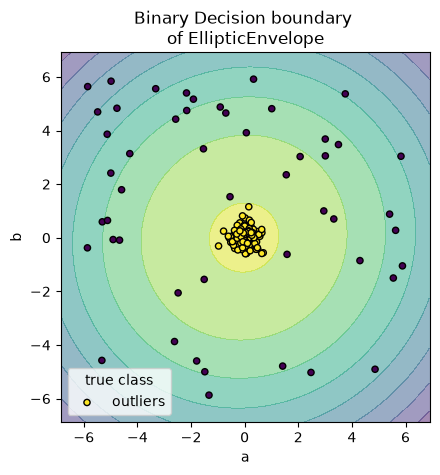

In [3]:
# Entrenamos un objeto de tipo EllipticEnvelope
algorithm = EllipticEnvelope(support_fraction=None, contamination=0.25,random_state=42)
outlier_method = algorithm.fit(df)

# Aplicamos el método de detección de outliers entrenado sobre nuesto dataset devuelve una nueva columna
df_outliers = outlier_method.predict(df)
print(df_outliers)

# Determinar la posición de los outliers
pos_outliers = np.where(df_outliers==-1)[0]
print('\nOutliers en la posición: \n', pos_outliers)

# Determinar el número de outliers
print('\nNúmero de outliers: \n', len(pos_outliers))

# Gráfico de la frontera de decisión para EllipticEnvelope
disp = DecisionBoundaryDisplay.from_estimator(
    algorithm,
    df,
    response_method="decision_function",
    alpha=0.5,
)
disp.ax_.scatter(df.a, df.b, c=df_outliers, s=20, edgecolor="k")
disp.ax_.set_title("Binary Decision boundary \nof EllipticEnvelope")
plt.axis("square")
plt.legend(labels=["outliers", "inliers"], title="true class")
plt.show()

In [4]:
# Definimos una función que, dado un determinado "df" y un "algorithm", 
# devuelva la matriz y la posición de outliers
def find_outliers(df, algorithm):
    outlier_method = algorithm.fit(df)
    
    #Aplicacmos el método de detección de outliers entrenado sobre nuestro dataset
    df_outliers = outlier_method.predict(df)
    print(df_outliers)
    
    #determinamos la posicion de los outliers
    pos_outliers=np.where(df_outliers==-1)[0]
    print('\nOutliers en la posición :\n', pos_outliers)
    
    #Determinamos el número de outliers
    print('\nNúmero de outliers: \n', len(pos_outliers))
    
    return df_outliers, pos_outliers


[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]

Outliers en la posición :
 [150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199]

Número de outliers: 
 50


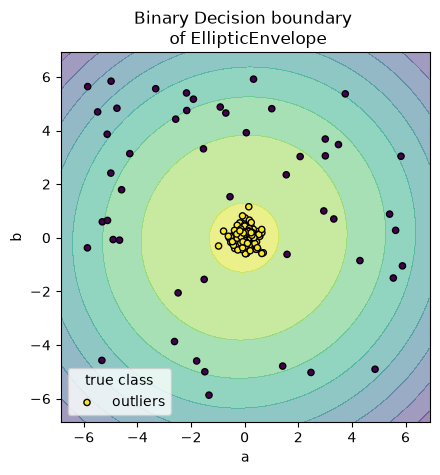

In [5]:
EE = EllipticEnvelope(support_fraction=None, contamination=0.25,random_state=42)
df_outliers, pos_outliers = find_outliers(df, EE)


# Generamos la visualización de la frontera de decisión para EllipticEnvelope
disp = DecisionBoundaryDisplay.from_estimator(
    EE,
    df,
    response_method="decision_function",
    alpha=0.5,
)

# Dibujamos los puntos del DataFrame sobre la gráfica
disp.ax_.scatter(df.a, df.b, c=df_outliers, s=20, edgecolor="k")
disp.ax_.set_title("Binary Decision boundary \n of EllipticEnvelope")
plt.axis("square")
plt.legend(labels=["outliers", "inliers"], title="true class")
plt.show()

In [6]:
# Eliminamos los outliers
new_df = df[df_outliers==1]
print(new_df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
145 -0.062437 -0.147900
146 -0.176809  0.254881
147  0.107105 -0.207873
148  0.269880  0.092190
149  0.243859  0.188889

[150 rows x 2 columns]


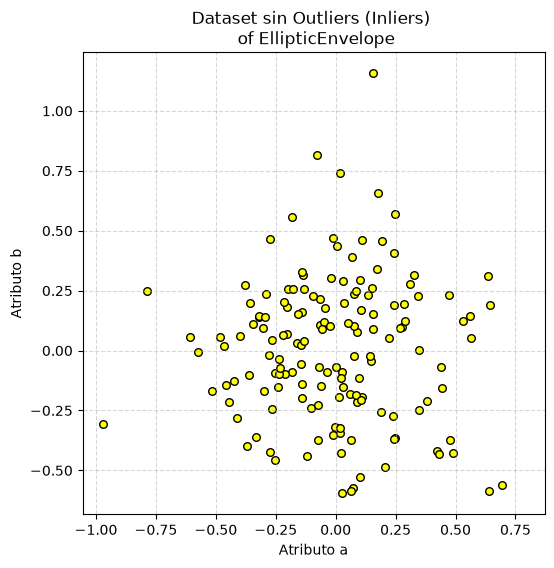

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(new_df['a'], new_df['b'], c='yellow', edgecolor='k', s=30)
plt.title("Dataset sin Outliers (Inliers) \n of EllipticEnvelope")
plt.xlabel("Atributo a")
plt.ylabel("Atributo b")
plt.axis("square")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### OTROS MÉTODOS SIMILARES

#### ISOLATION FOREST

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1  1 -1]

Outliers en la posición :
 [150 151 152 153 154 155 156 157 158 159 160 161 162 163 165 166 167 168
 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186
 187 188 189 190 191 192 193 194 195 196 197 199]

Número de outliers: 
 48


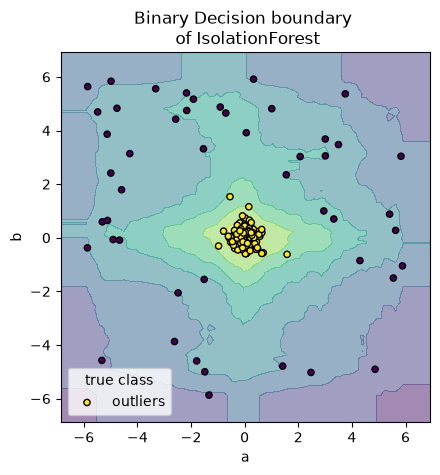

In [8]:

#  1. Isolation Forest ---
IF = IsolationForest(max_samples='auto', random_state=42)
df_outliers, pos_outliers = find_outliers(df, IF)

# Gráfico para Isolation Forest
disp = DecisionBoundaryDisplay.from_estimator(
    IF,
    df,
    response_method="decision_function",
    alpha=0.5,
)
disp.ax_.scatter(df.a, df.b, c=df_outliers, s=20, edgecolor="k")
disp.ax_.set_title("Binary Decision boundary \n of IsolationForest")
plt.axis("square")
plt.legend(labels=["outliers", "inliers"], title="true class")
plt.show()


In [9]:
# Eliminamos los outliers
new_df = df[df_outliers==1]
print(new_df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
147  0.107105 -0.207873
148  0.269880  0.092190
149  0.243859  0.188889
164  1.582047 -0.618654
198 -0.545507  1.530697

[152 rows x 2 columns]


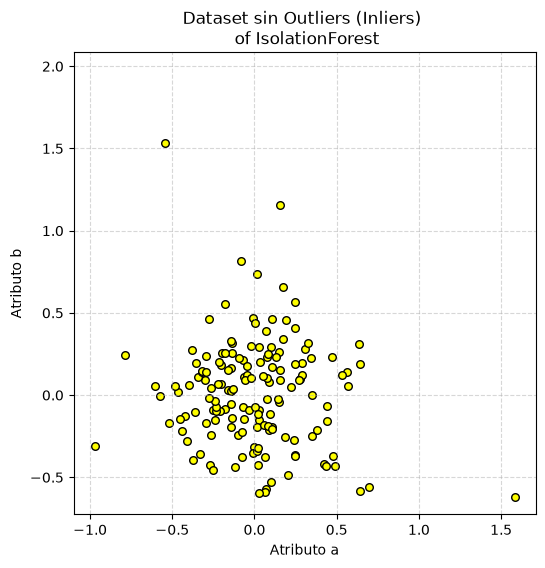

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(new_df['a'], new_df['b'], c='yellow', edgecolor='k', s=30)
plt.title("Dataset sin Outliers (Inliers) \n of IsolationForest")
plt.xlabel("Atributo a")
plt.ylabel("Atributo b")
plt.axis("square")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### ONE CLASS SVM

[ 1 -1  1 -1  1  1 -1 -1  1 -1  1 -1  1  1  1 -1  1 -1 -1 -1  1  1 -1  1
 -1  1  1  1  1  1  1 -1 -1  1  1 -1 -1 -1  1 -1  1 -1  1  1  1  1  1 -1
  1  1 -1  1  1 -1  1 -1 -1  1  1  1  1 -1 -1  1  1 -1  1 -1  1 -1  1 -1
  1 -1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1 -1  1
  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1 -1  1  1  1  1  1 -1 -1  1
  1  1  1  1 -1 -1 -1 -1  1  1  1 -1  1 -1  1 -1  1  1  1  1  1 -1 -1  1
  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]

Outliers en la posición :
 [  1   3   6   7   9  11  15  17  18  19  22  24  31  32  35  36  37  39
  41  47  50  53  55  56  61  62  65  67  69  71  73  78  83  89  94 102
 104 110 111 117 118 124 125 126 127 131 133 135 141 142 150 151 152 153
 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171
 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 1

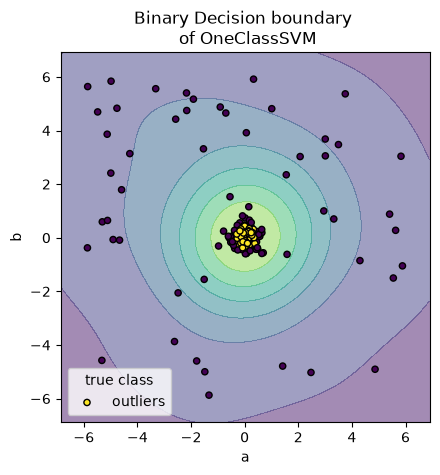

In [11]:

# --- 2. One Class SVM ---
OC_SVM = OneClassSVM(kernel='rbf', gamma='scale', nu=0.5)
df_outliers, pos_outliers = find_outliers(df, OC_SVM)

# Gráfico para One Class SVM
disp = DecisionBoundaryDisplay.from_estimator(
    OC_SVM,
    df,
    response_method="decision_function",
    alpha=0.5,
)
disp.ax_.scatter(df.a, df.b, c=df_outliers, s=20, edgecolor="k")
disp.ax_.set_title("Binary Decision boundary \n of OneClassSVM")
plt.axis("square")
plt.legend(labels=["outliers", "inliers"], title="true class")
plt.show()

In [12]:
# Eliminamos los outliers
new_df = df[df_outliers==1]
print(new_df)

            a         b
0    0.149014 -0.041479
2   -0.070246 -0.070241
4   -0.140842  0.162768
5   -0.139025 -0.139719
8   -0.303849  0.094274
..        ...       ...
145 -0.062437 -0.147900
146 -0.176809  0.254881
147  0.107105 -0.207873
148  0.269880  0.092190
149  0.243859  0.188889

[100 rows x 2 columns]


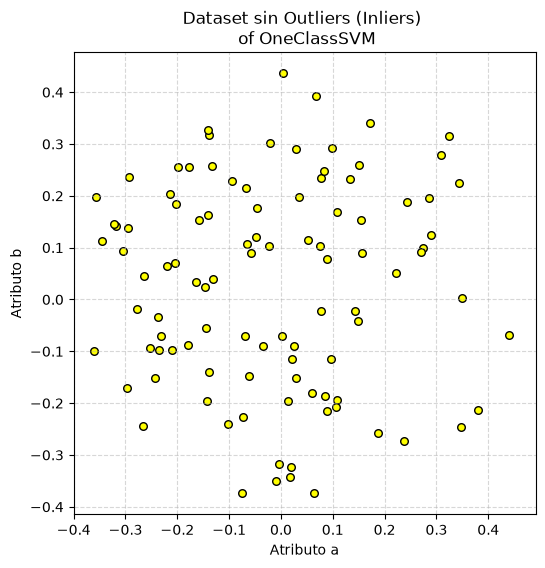

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(new_df['a'], new_df['b'], c='yellow', edgecolor='k', s=30)
plt.title("Dataset sin Outliers (Inliers) \n of OneClassSVM")
plt.xlabel("Atributo a")
plt.ylabel("Atributo b")
plt.axis("square")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### LOCAL OUTLIER FACTOR

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1 -1 -1 -1 -1  1 -1 -1  1 -1  1 -1 -1  1 -1 -1 -1 -1 -1
 -1 -1 -1 -1  1 -1  1  1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1  1
  1  1 -1 -1 -1 -1 -1 -1]

Outliers en la posición :
 [ 37  56  89 104 110 126 131 142 150 151 152 153 155 156 158 160 161 163
 164 165 166 167 168 169 170 171 173 176 178 179 180 181 182 183 184 185
 186 187 188 189 194 195 196 197 198 199]

Número de outliers: 
 46


C:\Users\JUDY\anaconda3\envs\machinelearning2026nocturno\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\JUDY\anaconda3\envs\machinelearning2026nocturno\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


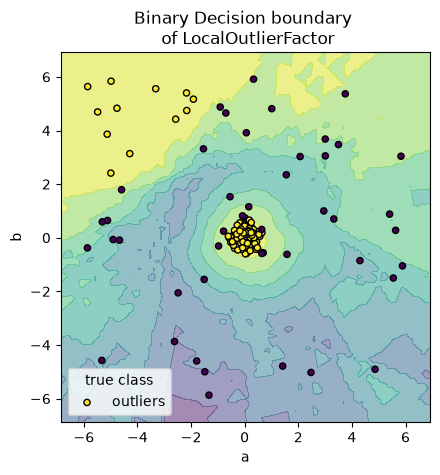

In [14]:
# --- 3. Local Outlier Factor ---
LOF = LocalOutlierFactor(n_neighbors=20, contamination='auto', novelty=True)
df_outliers, pos_outliers = find_outliers(df, LOF)

# Gráfico para Local Outlier Factor
disp = DecisionBoundaryDisplay.from_estimator(
    LOF,
    df,
    response_method="decision_function",
    alpha=0.5,
)
disp.ax_.scatter(df.a, df.b, c=df_outliers, s=20, edgecolor="k")
disp.ax_.set_title("Binary Decision boundary \n of LocalOutlierFactor")
plt.axis("square")
plt.legend(labels=["outliers", "inliers"], title="true class")
plt.show()

In [15]:
# Eliminamos los outliers
new_df = df[df_outliers==1]
print(new_df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
177 -4.981947  5.839675
190 -2.571455  4.423190
191 -3.316850  5.558670
192 -5.854146  5.638546
193 -5.482081  4.693717

[154 rows x 2 columns]


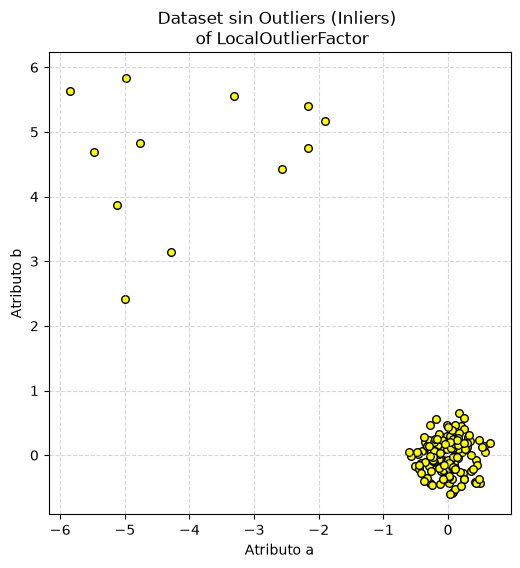

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(new_df['a'], new_df['b'], c='yellow', edgecolor='k', s=30)
plt.title("Dataset sin Outliers (Inliers) \n of LocalOutlierFactor")
plt.xlabel("Atributo a")
plt.ylabel("Atributo b")
plt.axis("square")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [17]:
df.head(10)

,a,b
0,0.149014,-0.041479
1,0.194307,0.456909
2,-0.070246,-0.070241
3,0.473764,0.230230
4,-0.140842,0.162768
5,-0.139025,-0.139719
6,0.072589,-0.573984
7,-0.517475,-0.168686
8,-0.303849,0.094274
9,-0.272407,-0.423691


### Box plot

limite inferior:  -1.0853060827395105
limite superior:  1.0119554520872196
Posición de outliers:  [150 153 154 157 159 160 162 165 168 169 171 172 174 175 177 178 181 184
 185 186 187 190 191 192 193 195 151 152 155 156 161 163 164 166 167 173
 176 179 180 182 188 189 196 197]
Número de outliers:  44


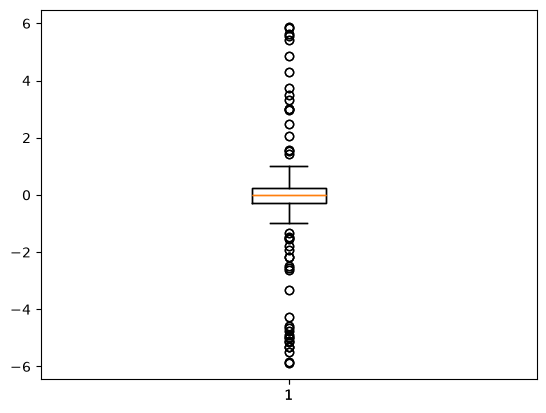

In [18]:
# Seleccionamos el atributo que vamos a medir
a = df['a']

# Seleccionamos los umbrales a partir de los cuales vamos a considerar outliers
Q1 = stats.scoreatpercentile(a, 25)
Q3 = stats.scoreatpercentile(a, 75)

#Rango intercuartílico que ayuda a evidenciar la separación de los datos fuera de este rango
RIC = Q3 - Q1
li = Q1 - 1.5*RIC #xmin
ls = Q3 + 1.5*RIC #xmax

# Observamos los límites inferior y superior
print('limite inferior: ', li)
print('limite superior: ', ls)

# Buscamos la posición de los outliers
pos_i = np.where(a<li)[0]
pos_s = np.where(a>ls)[0]
pos_outliers = np.concatenate((pos_i, pos_s)) 
print('Posición de outliers: ', pos_outliers)
print('Número de outliers: ', len(pos_outliers))

# Dibujamos el diagrama de caja y bigotes
prop = plt.boxplot(a)
plt.boxplot(a)
plt.show()

In [19]:
# Eliminamos los outliers
new_df = df.drop(index=pos_outliers)
print(new_df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
170 -0.701634  4.652450
183 -0.909336  4.876253
194  0.332413  5.915578
198 -0.545507  1.530697
199  1.011772  4.813896

[156 rows x 2 columns]


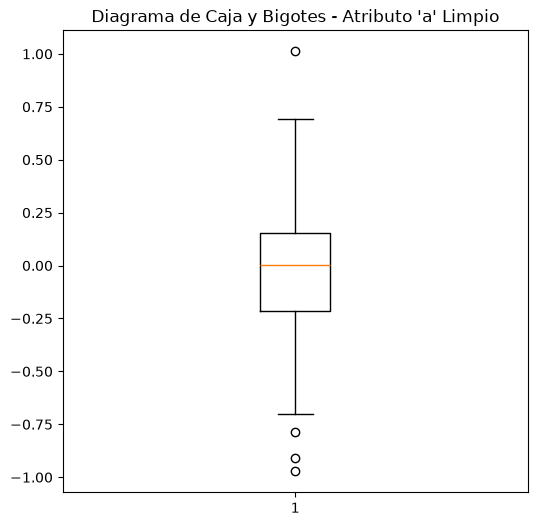

In [20]:
# Gráfico de caja y bigotes con los datos limpios (la columna 'a' ya sin outliers)
plt.figure(figsize=(6, 6))
plt.boxplot(new_df['a'])
plt.title("Diagrama de Caja y Bigotes - Atributo 'a' Limpio")
plt.show()

In [21]:
# Definir una función que, dada una columna de un dataframe, 
# devuelva la posición de los outliers según el método box plot
def find_limits_BP(variable):
    Q1 = stats.scoreatpercentile(a, 25)
    Q3 = stats.scoreatpercentile(a, 75)

    RIC = Q3 - Q1
    
    li = Q1 - 1.5*RIC #xmin
    ls = Q3 + 1.5*RIC #xmax

    pos_i = np.where(a < li)[0]
    pos_s = np.where(a > ls)[0]
    pos_outliers = np.concatenate((pos_i, pos_s))

    return pos_outliers, li, ls


Límite inferior: -1.0853060827395105
Límite superior: 1.0119554520872196
Posición de los outliers: [150 153 154 157 159 160 162 165 168 169 171 172 174 175 177 178 181 184
 185 186 187 190 191 192 193 195 151 152 155 156 161 163 164 166 167 173
 176 179 180 182 188 189 196 197]
Número de outliers:  44


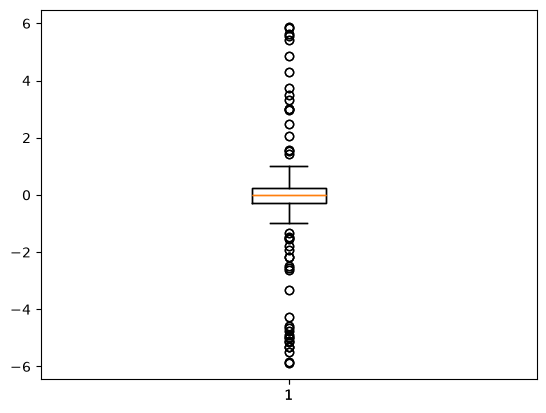

In [22]:
# Variable a medir
a = df['a']

# Función a la columna 'a' del dataframe
outliers_idx, limite_inferior, limite_superior = find_limits_BP(df['a'])
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Posición de los outliers:", pos_outliers)
print('Número de outliers: ', len(pos_outliers))

prop = plt.boxplot(a)
plt.boxplot(a)
plt.show()


In [23]:
# Eliminamos los outliers
new_df = df.drop(index=pos_outliers)
print(new_df)

            a         b
0    0.149014 -0.041479
1    0.194307  0.456909
2   -0.070246 -0.070241
3    0.473764  0.230230
4   -0.140842  0.162768
..        ...       ...
170 -0.701634  4.652450
183 -0.909336  4.876253
194  0.332413  5.915578
198 -0.545507  1.530697
199  1.011772  4.813896

[156 rows x 2 columns]


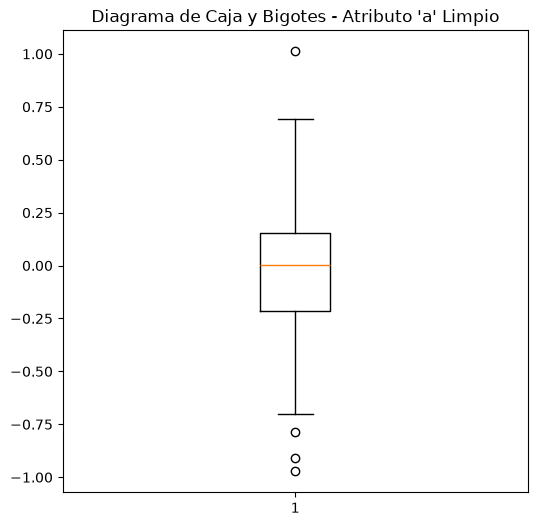

In [24]:
# Gráfico de caja y bigotes con los datos limpios (la columna 'a' ya sin outliers)
plt.figure(figsize=(6, 6))
plt.boxplot(new_df['a'])
plt.title("Diagrama de Caja y Bigotes - Atributo 'a' Limpio")
plt.show()

In [25]:
# Creamos un bucle for que estime los valores outliers de cada atributo
headers = df.columns # nombre de los atributos del CSV
pos_outliers = []
for i in range(len(headers)):
    variable = df[headers[i]] # Atributo 'x'
    pos_out, _, _ = find_limits_BP(variable) # Llamamos a la función que hemos creado
    pos_outliers.append(pos_out) # Lo añadimos en una lista

# Concatenamos todas las posiciones de outliers
po = np.vstack(pos_outliers)

# Vemos las posiciones de todos los outliers
pos_out = np.unique(po)
print('Posiciones de outliers: ', pos_out)

# Observamos el número de outliers
print('Numero de outliers: ', len(pos_out))

Posiciones de outliers:  [150 151 152 153 154 155 156 157 159 160 161 162 163 164 165 166 167 168
 169 171 172 173 174 175 176 177 178 179 180 181 182 184 185 186 187 188
 189 190 191 192 193 195 196 197]
Numero de outliers:  44
